In [8]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler


In [9]:
seed_af_dir = "../../part1_refoldunfold/2_structure_prediction/parsed_results"
pseudo_af_dir = "../../part2_gpc_training/2_structure_prediction/parsed_results"
swissprot_dir = "../../part2_gpc_training/2_structure_prediction/parsed_results"

CONFIG = {
    "feats": ["length", "pTM", "pLDDT mean"],
    "target_col": "source",
    "pos_label": "AntiFam",
    "n_cv_splits": 5,
    "random_state": 42,
    "resample_balanced": {"n_af": 100, "n_sp": 100},
    "resample_unbalanced": {"n_af": 20, "n_sp": 980},
}


MODELS = {
    "af3": {"name": "AlphaFold3", "color": "#4169C8", "file": "af3_info.csv"},
    "colabfold": {
        "name": "AlphaFold2",
        "color": "#D43FA0",
        "file": "colabfold_info.csv",
    },
    "esmfold": {"name": "ESMFold", "color": "#F5A830", "file": "esmfold_info.csv"},
}

DARK_COLORS = {
    "colabfold": "#8B0068",
    "af3": "#1A3A8A",
    "esmfold": "#8A5200",
}

DATA_SOURCES = {
    "af_train": {
        "dir": seed_af_dir,
        "prefix": "af_res_",
        "source": "AntiFam",
        "af_source": "Seed",
    },
    "af_test": {
        "dir": pseudo_af_dir,
        "prefix": "pseudo_antifams_",
        "source": "AntiFam",
        "af_source": "Generated",
    },
    "sp_train": {"dir": swissprot_dir, "prefix": "train_", "source": "Swiss-Prot"},
    "sp_test2": {"dir": swissprot_dir, "prefix": "test2_", "source": "Swiss-Prot"},
}

TEST_SAMPLES = {"af_test2": 100, "af_test50": 300, "sp_test98": 4900, "sp_test50": 300}


def load_csv(filepath, source, af_source=None):
    df = pd.read_csv(filepath)
    if "Unnamed: 0" in df.columns:
        df = df.rename(columns={"Unnamed: 0": "id"})
    df["source"] = source
    if af_source:
        df["AntiFam source"] = af_source
        if af_source == "Seed":
            df["anf_num"] = df["id"].str.extract(r"ANF0*(\d+)")[0].astype(int)
            df["seq_num"] = df["id"].str.extract(r"seq_(\d+)")[0].astype(int)
            df = df.sort_values(["anf_num", "seq_num"]).reset_index(drop=True)
            df["anf_prefix"] = df["id"].str.extract(r"(ANF\d+)")
            df = df[df.groupby("anf_prefix")["id"].transform("first") == df["id"]]
            df = df[df["id"] != "ANF00264_seq_1"]
            df = df.drop(columns=["anf_num", "seq_num", "anf_prefix"]).reset_index(
                drop=True
            )
    return df


In [10]:
def train_gpc_model(X_train, y_train, random_state=42):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    gpc = GaussianProcessClassifier(
        kernel=RBF(length_scale=1.0),
        random_state=random_state,
        max_iter_predict=1000,
    )
    gpc.fit(X_scaled, y_train)
    return gpc, scaler


def get_predictions(model, scaler, X, pos_label="AntiFam"):
    X_scaled = scaler.transform(X)
    positive_idx = list(model.classes_).index(pos_label)
    return model.predict_proba(X_scaled)[:, positive_idx]


def compute_metrics(y_binary, y_proba):
    fpr, tpr, roc_thresh = roc_curve(y_binary, y_proba)
    precision, recall, pr_thresh = precision_recall_curve(y_binary, y_proba)
    y_pred = (y_proba >= 0.5).astype(int)
    tp = ((y_pred == 1) & (y_binary == 1)).sum()
    fp = ((y_pred == 1) & (y_binary == 0)).sum()
    fn = ((y_pred == 0) & (y_binary == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return {
        "auc": auc(fpr, tpr),
        "average_precision": average_precision_score(y_binary, y_proba),
        "accuracy": (y_pred == y_binary).mean(),
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresh,
        "precision": precision,
        "recall": recall,
        "pr_thresholds": pr_thresh,
    }


def find_optimal_threshold_at_fpr_zero(fpr, tpr, thresholds):
    mask = fpr == 0
    if not np.any(mask):
        idx = np.argmin(fpr)
        return thresholds[idx], tpr[idx], fpr[idx]
    best = np.argmax(tpr[mask])
    return thresholds[mask][best], tpr[mask][best], 0.0


def find_recall_at_100_precision(precision, recall):
    mask = precision == 1.0
    if not np.any(mask):
        idx = np.argmax(precision)
        return recall[idx], precision[idx]
    return np.max(recall[mask]), 1.0

In [11]:
def cross_validate_model(train_df, config):
    feature_cols = config["feats"]
    pos_label = config["pos_label"]
    rs = config["random_state"]

    X = train_df[feature_cols].values
    y = train_df["source"].values
    y_binary = (y == pos_label).astype(int)

    cv = StratifiedKFold(n_splits=config["n_cv_splits"], shuffle=True, random_state=rs)
    cv_aucs, cv_recalls = [], []

    for train_idx, val_idx in cv.split(X, y_binary):
        model, scaler = train_gpc_model(X[train_idx], y[train_idx], rs)
        y_proba = get_predictions(model, scaler, X[val_idx], pos_label)
        m = compute_metrics(y_binary[val_idx], y_proba)
        cv_aucs.append(m["auc"])
        recall, _ = find_recall_at_100_precision(m["precision"], m["recall"])
        cv_recalls.append(recall)

    return {
        "cv_auc_mean": np.mean(cv_aucs),
        "cv_auc_std": np.std(cv_aucs),
        "cv_recall_mean": np.mean(cv_recalls),
        "cv_recall_std": np.std(cv_recalls),
    }

In [12]:
def _style_ax(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["bottom", "left"]:
        ax.spines[spine].set_color("#CCCCCC")
        ax.spines[spine].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.7)
    ax.set_axisbelow(True)


def plot_precision_recall_curves(pr_curves, model_name, model_color):
    fig, ax = plt.subplots(figsize=(4, 4))
    recalls_test2, recalls_test50 = [], []

    for test_name, alpha, recall_list in [
        ("Test_2%", 0.5, recalls_test2),
        ("Test_50%", 1.0, recalls_test50),
    ]:
        if test_name not in pr_curves:
            continue
        data = pr_curves[test_name]
        if isinstance(data, dict):
            data = [data]
        for curve in data:
            ax.plot(
                curve["recall"],
                curve["precision"],
                color=model_color,
                alpha=alpha,
                linewidth=1.5,
            )
            max_r = max(
                (r for p, r in zip(curve["precision"], curve["recall"]) if p >= 1.0),
                default=None,
            )
            if max_r is not None:
                recall_list.append(max_r)

    for recall_list, ls in [(recalls_test2, ":"), (recalls_test50, "--")]:
        if recall_list:
            ax.axvline(
                np.mean(recall_list),
                color=model_color,
                linestyle=ls,
                alpha=0.5 if ls == ":" else 1.0,
                linewidth=1.5,
            )

    ax.legend(
        handles=[
            Line2D(
                [0], [0], color=model_color, alpha=0.5, linewidth=2, label="Test 2%"
            ),
            Line2D([0], [0], color=model_color, linewidth=2, label="Test 50%"),
        ],
        loc="lower left",
    )
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"{model_name} GPC", fontsize=14)
    plt.tight_layout()
    fig.savefig(
        f"{model_name.replace(' ', '_')}_pr_curves.png", dpi=150, bbox_inches="tight"
    )
    plt.show()


# def plot_simple_precision_recall_curves(pr_curves, model_name, model_color, ax):
#     recalls_test2, recalls_test50 = [], []

#     for test_name, alpha, recall_list in [
#         ("Test_2%", 1.0, recalls_test2),
#         ("Test_50%", 0.5, recalls_test50),
#     ]:
#         if test_name not in pr_curves:
#             continue
#         data = pr_curves[test_name]
#         if isinstance(data, dict):
#             data = [data]
#         for curve in data:
#             ax.plot(
#                 curve["recall"],
#                 curve["precision"],
#                 color=model_color,
#                 alpha=alpha,
#                 linewidth=4,
#             )
#             max_r = max(
#                 (r for p, r in zip(curve["precision"], curve["recall"]) if p >= 1.0),
#                 default=None,
#             )
#             if max_r is not None:
#                 recall_list.append(max_r)

#     for recall_list, ls in [(recalls_test2, "--"), (recalls_test50, ":")]:
#         if recall_list:
#             ax.axvline(
#                 np.mean(recall_list),
#                 color=model_color,
#                 linestyle=ls,
#                 alpha=0.5 if ls == ":" else 1,
#                 linewidth=5 if ls == ":" else 4,
#             )

#     ax.spines[["top", "right"]].set_visible(False)
#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1.05)
#     ax.set_xticks([0, 0.5, 1.0])
#     ax.set_yticks([0, 0.5, 1.0])
#     ax.tick_params(axis="both", length=4, width=1, labelsize=14)
#     ax.set_xlabel("Recall", fontsize=16)
#     ax.set_title(f"{model_name} GPC", fontsize=18, pad=8)

#     # y label on leftmost panel only — handled by caller


# def plot_all_pr_curves(all_pr_curves):

#     n = len(all_pr_curves)
#     fig, axes = plt.subplots(1, n, figsize=(9, 3.5), sharey=True)

#     for i, (model_name, model_color, pr_curves) in enumerate(all_pr_curves):
#         ax = axes[i]
#         plot_simple_precision_recall_curves(pr_curves, model_name, model_color, ax)
#         if i == 0:
#             ax.set_ylabel("Precision", fontsize=16)
#         else:
#             ax.set_ylabel("")

#     # Single shared legend beneath all panels — 2 rows of 2
#     fig.legend(
#         handles=[
#             Line2D(
#                 [0],
#                 [0],
#                 color="grey",
#                 linewidth=4,
#                 linestyle="-",
#                 label="Unbalanced (2%)",
#             ),
#             Line2D(
#                 [0],
#                 [0],
#                 color="grey",
#                 linewidth=4,
#                 linestyle="-",
#                 alpha=0.4,
#                 label="Balanced (50%)",
#             ),
#             Line2D(
#                 [0],
#                 [0],
#                 color="grey",
#                 linewidth=2,
#                 linestyle="--",
#                 label="Recall at 100% precision (2%)",
#             ),
#             Line2D(
#                 [0],
#                 [0],
#                 color="grey",
#                 linewidth=2,
#                 linestyle=":",
#                 alpha=0.5,
#                 label="Recall at 100% precision (50%)",
#             ),
#         ],
#         loc="lower center",
#         ncol=2,
#         fontsize=12,
#         frameon=False,
#         bbox_to_anchor=(0.5, -0.05),
#     )

#     plt.tight_layout()
#     plt.subplots_adjust(bottom=0.3)
#     fig.savefig("all_models_pr_curves.png", dpi=150, bbox_inches="tight")
#     plt.show()


def plot_combined_roc_curves(all_model_data, test_type="Test_50%"):
    fig, ax = plt.subplots(figsize=(4, 4))
    for model_data in all_model_data:
        if test_type not in model_data["roc_curves"]:
            continue
        data = model_data["roc_curves"][test_type]
        opt_thresh, opt_tpr, opt_fpr = find_optimal_threshold_at_fpr_zero(
            data["fpr"], data["tpr"], data["thresholds"]
        )
        ax.plot(
            data["fpr"],
            data["tpr"],
            color=model_data["color"],
            lw=1.5,
            alpha=0.8,
            label=f"{model_data['name']} (AUC = {data['auc']:.3f})",
        )
        ax.scatter(
            [opt_fpr], [opt_tpr], color=model_data["color"], s=30, alpha=0.8, zorder=5
        )
        ax.annotate(
            f"{opt_thresh:.3f}",
            xy=(opt_fpr, opt_tpr),
            xytext=(opt_fpr + 0.02, opt_tpr),
            fontsize=8,
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.legend(loc="lower right", fontsize=9)
    _style_ax(ax)
    plt.tight_layout()
    fig.savefig(f"combined_roc_{test_type}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


In [13]:
def classify_trend(means, threshold=0.02):
    if len(means) < 3:
        return "insufficient data"
    gain = means[-1] - means[-3]
    if abs(gain) < threshold:
        return "plateaued"
    return "improving" if gain > 0 else "degrading"


def run_learning_curves(fractions=None, n_seeds=5):
    if fractions is None:
        fractions = [0.10, 0.25, 0.50, 0.75, 1.00]

    metrics = ["auc", "accuracy", "average_precision", "recall_at_100_precision"]
    test_names = ["Test_50%", "Test_2%"]
    results = {
        mk: {f: {t: {m: [] for m in metrics} for t in test_names} for f in fractions}
        for mk in MODELS
    }
    test_set_info = {}

    for model_key, model in MODELS.items():
        print(f"\nLearning curves for {model['name']}...")
        train_df = model["training"]
        feature_cols = CONFIG["feats"]
        pos_label = CONFIG["pos_label"]

        test_sets = {}
        for name in test_names:
            test_df = model["testing"][name]
            counts = test_df["source"].value_counts().to_dict()
            test_sets[name] = {
                "X": test_df[feature_cols].values,
                "y_binary": (test_df["source"].values == pos_label).astype(int),
                "counts": counts,
                "total": len(test_df),
            }
            test_set_info[f"{model['name']} — {name}"] = {
                "total": len(test_df),
                "counts": counts,
            }
            count_str = ", ".join(f"{s}: {n}" for s, n in sorted(counts.items()))
            print(f"  {name}: {len(test_df)} total ({count_str})")

        for frac in fractions:
            train_counts = {
                src: max(1, int(len(grp) * frac))
                for src, grp in train_df.groupby("source")
            }
            count_str = ", ".join(f"{s}: ~{n}" for s, n in sorted(train_counts.items()))
            n_sample = int(len(train_df) * frac) if frac < 1.0 else len(train_df)
            print(f"  {int(frac * 100):3d}% (~{n_sample}: {count_str})")

            for seed in range(n_seeds):
                sample = (
                    pd.concat(
                        [
                            grp.sample(frac=frac, random_state=seed)
                            for _, grp in train_df.groupby("source")
                        ]
                    ).reset_index(drop=True)
                    if frac < 1.0
                    else train_df
                )
                model_fit, scaler = train_gpc_model(
                    sample[feature_cols].values,
                    sample["source"].values,
                    random_state=seed,
                )
                for test_name, td in test_sets.items():
                    y_proba = get_predictions(model_fit, scaler, td["X"], pos_label)
                    m = compute_metrics(td["y_binary"], y_proba)
                    recall_100, _ = find_recall_at_100_precision(
                        m["precision"], m["recall"]
                    )
                    for metric in ["auc", "accuracy", "average_precision"]:
                        results[model_key][frac][test_name][metric].append(m[metric])
                    results[model_key][frac][test_name][
                        "recall_at_100_precision"
                    ].append(recall_100)

            for test_name in test_names:
                for metric in metrics:
                    vals = results[model_key][frac][test_name][metric]
                    print(
                        f"    [{test_name}] {metric.upper():25s}: "
                        f"{np.mean(vals):.3f} ± {np.std(vals):.3f}"
                    )

    return results, test_set_info


def plot_learning_curves(lc_results, fractions=None):
    if fractions is None:
        fractions = [0.10, 0.25, 0.50, 0.75, 1.00]

    results, test_set_info = lc_results
    test_names = ["Test_50%", "Test_2%"]
    metrics = ["auc", "accuracy", "average_precision", "recall_at_100_precision"]
    metric_labels = {
        "auc": "AUC",
        "accuracy": "Accuracy",
        "average_precision": "Avg. precision",
        "recall_at_100_precision": "Recall at 100% precision",
    }
    y_floors = {
        "auc": 0.5,
        "accuracy": 0.5,
        "average_precision": 0.5,
        "recall_at_100_precision": 0.0,
    }
    test_titles = {"Test_50%": "Balanced (50/50)", "Test_2%": "Unbalanced (2/98)"}

    fig, axes = plt.subplots(
        len(metrics), len(test_names), figsize=(8, 3 * len(metrics)), sharey="row"
    )
    plateau_report = {m: {} for m in metrics}

    for row, metric in enumerate(metrics):
        for col, test_name in enumerate(test_names):
            ax = axes[row][col]
            for i, (model_key, model) in enumerate(MODELS.items()):
                means = [
                    np.mean(results[model_key][f][test_name][metric]) for f in fractions
                ]
                stds = [
                    np.std(results[model_key][f][test_name][metric]) for f in fractions
                ]
                pct = [f * 100 for f in fractions]

                ax.plot(
                    pct,
                    means,
                    color=model["color"],
                    lw=2,
                    marker="o",
                    markersize=5,
                    label=model["name"],
                )
                ax.fill_between(
                    pct,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    color=model["color"],
                    alpha=0.15,
                )

                # --- NEW: staggered annotation offset ---
                # offset = 0.01 * (i - len(MODELS) / 2)

                # ax.annotate(
                #     f"{means[-1]:.3f}",
                #     xy=(100, means[-1]),
                #     xytext=(101, means[-1] + offset),
                #     fontsize=8,
                #     color=DARK_COLORS[model_key],
                #     va="center",
                # )

                if test_name == "Test_2%":
                    plateau_report[metric][model["name"]] = {
                        "trend": classify_trend(means),
                        "means": means,
                        "gain_75_to_100": means[-1] - means[-2],
                        "gain_50_to_100": means[-1] - means[-3],
                        "final_mean": means[-1],
                        "final_std": stds[-1],
                    }

            if row == 0:
                info = test_set_info.get(
                    f"{list(MODELS.values())[0]['name']} — {test_name}", {}
                )
                count_label = ", ".join(
                    f"{s}: {n}" for s, n in sorted(info.get("counts", {}).items())
                )
                ax.set_title(
                    f"GPC — {test_titles[test_name]}\n"
                    f"n={info.get('total', '?')} ({count_label})",
                    fontsize=10,
                )
            # After the model loop, do label placement in a second pass
            # Collect final values per model for this subplot
            final_means_for_labels = []
            for model_key, model in MODELS.items():
                means = [
                    np.mean(results[model_key][f][test_name][metric]) for f in fractions
                ]
                final_means_for_labels.append(
                    (means[-1], model["color"], model["name"])
                )

            # Sort by final value so we can assign non-overlapping y offsets
            final_means_for_labels.sort(key=lambda x: x[0])
            n = len(final_means_for_labels)
            label_step = 0.025  # vertical gap between labels

            for rank, (val, color, name) in enumerate(final_means_for_labels):
                # Centre the label cluster around the median value, spread by rank
                median_rank = (n - 1) / 2
                y_offset = val + (rank - median_rank) * label_step
                ax.annotate(
                    f"{val:.3f}",
                    xy=(fractions[-1] * 100, val),
                    xytext=(fractions[-1] * 100 + 2, y_offset),
                    fontsize=7,
                    color=color,
                    va="center",
                    annotation_clip=False,
                )

            ax.set_xlabel("Training set fraction (%)", fontsize=10)
            ax.set_ylabel(metric_labels[metric], fontsize=10)
            ax.set_xticks([f * 100 for f in fractions])
            ax.set_xlim(5, 125)
            ax.set_ylim(y_floors[metric], 1.05)
            _style_ax(ax)
    handles = [
        plt.Line2D(
            [0],
            [0],
            color=model["color"],
            lw=2,
            marker="o",
            markersize=5,
            label=model["name"],
        )
        for model in MODELS.values()
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(MODELS),
        fontsize=9,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)  # make room for the legend
    plt.tight_layout()
    fig.savefig("learning_curves_all_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n{'=' * 60}\nPlateau report (Test_2% — unbalanced)\n{'=' * 60}")
    for metric in metrics:
        print(f"\n  {metric_labels[metric]}")
        for name, rep in plateau_report[metric].items():
            print(f"    {name}: {rep['trend']}")
            print(
                f"      Final:        {rep['final_mean']:.3f} ± {rep['final_std']:.3f}"
            )
            print(f"      Gain 75→100%: {rep['gain_75_to_100']:+.3f}")
            print(f"      Gain 50→100%: {rep['gain_50_to_100']:+.3f}")
            print(f"      All means:    {[round(m, 3) for m in rep['means']]}")

    return plateau_report


def plot_recall_learning_curves(lc_results, fractions=None):
    if fractions is None:
        fractions = [0.10, 0.25, 0.50, 0.75, 1.00]

    results, test_set_info = lc_results
    test_names = ["Test_50%", "Test_2%"]
    test_titles = {"Test_50%": "Balanced (50/50)", "Test_2%": "Unbalanced (2/98)"}
    metric = "recall_at_100_precision"

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

    for col, test_name in enumerate(test_names):
        ax = axes[col]

        final_means_for_labels = []
        for model_key, model in MODELS.items():
            means = [
                np.mean(results[model_key][f][test_name][metric]) for f in fractions
            ]
            stds = [np.std(results[model_key][f][test_name][metric]) for f in fractions]
            pct = [f * 100 for f in fractions]

            ax.plot(pct, means, color=model["color"], lw=2, marker="o", markersize=5)
            ax.fill_between(
                pct,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                color=model["color"],
                alpha=0.15,
            )
            final_means_for_labels.append((means[-1], model["color"], model["name"]))

        final_means_for_labels.sort(key=lambda x: x[0])
        n = len(final_means_for_labels)
        for rank, (val, color, name) in enumerate(final_means_for_labels):
            y_offset = val + (rank - (n - 1) / 2) * 0.03
            ax.annotate(
                f"{val:.3f}",
                xy=(fractions[-1] * 100, val),
                xytext=(fractions[-1] * 100 + 2, y_offset),
                fontsize=7,
                color=color,
                va="center",
                annotation_clip=False,
            )

        info = test_set_info.get(
            f"{list(MODELS.values())[0]['name']} — {test_name}", {}
        )
        count_label = ", ".join(
            f"{s}: {n}" for s, n in sorted(info.get("counts", {}).items())
        )
        ax.set_title(
            f"GPC — {test_titles[test_name]}\nn={info.get('total', '?')} ({count_label})",
            fontsize=10,
        )
        ax.set_xlabel("Training set fraction (%)", fontsize=10)
        ax.set_ylabel("Recall at 100% precision", fontsize=10)
        ax.set_xticks([f * 100 for f in fractions])
        ax.set_xlim(5, 125)
        ax.set_ylim(0, 1.05)
        _style_ax(ax)

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=model["color"],
            lw=2,
            marker="o",
            markersize=5,
            label=model["name"],
        )
        for model in MODELS.values()
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(MODELS),
        fontsize=9,
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    fig.savefig("recall_learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


  AlphaFold3 — train: 554, AF pool: 1275, SP pool: 4825
  AlphaFold2 — train: 554, AF pool: 1275, SP pool: 4900
  ESMFold — train: 554, AF pool: 1275, SP pool: 4900

Building test sets...

AlphaFold3 pool: AF=1275, SP=4825

AlphaFold3 final sets:
  Training: AF=16-886 (avg: 120.55), SP=17-100 (avg: 68.70)
  Test_50%: AF=31-869 (avg: 177.75), SP=46-945 (avg: 326.96)
  Test_2%:  AF=35-934 (avg: 186.25), SP=18-1545 (avg: 309.60)
  100 draws of 100 AF + 100 SP
  Test_2%: AF=100, SP=4825

AlphaFold2 pool: AF=1275, SP=4900

AlphaFold2 final sets:
  Training: AF=16-886 (avg: 120.55), SP=17-100 (avg: 68.70)
  Test_50%: AF=31-869 (avg: 177.75), SP=49-968 (avg: 306.08)
  Test_2%:  AF=32-973 (avg: 208.84), SP=18-1545 (avg: 309.31)
  100 draws of 100 AF + 100 SP
  Test_2%: AF=100, SP=4900

ESMFold pool: AF=1275, SP=4900

ESMFold final sets:
  Training: AF=16-886 (avg: 120.55), SP=17-100 (avg: 68.70)
  Test_50%: AF=31-869 (avg: 177.75), SP=49-968 (avg: 306.08)
  Test_2%:  AF=32-940 (avg: 212.67), S

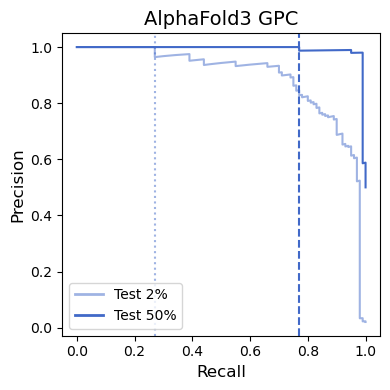


Running pipeline for: AlphaFold2
  CV AUC:          0.986 ± 0.008
  CV Recall@100P:  0.787 ± 0.087

Test Set Results:
test_set     auc  average_precision  accuracy       f1  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision  cv_auc_mean  cv_auc_std  cv_recall_mean  cv_recall_std
Test_50% 0.97980           0.985917      0.86 0.873874             0.78           0.789751                     0.78      0.98595    0.008178        0.787078       0.087122
 Test_2% 0.96342           0.865924      0.74 0.127517             0.46           0.945309                     0.46      0.98595    0.008178        0.787078       0.087122


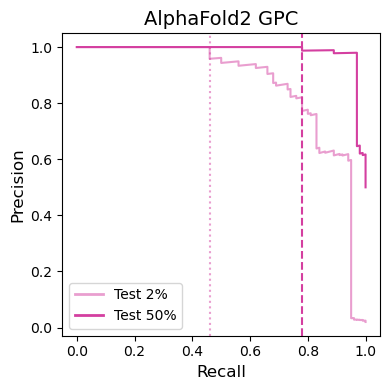


Running pipeline for: ESMFold
  CV AUC:          0.980 ± 0.008
  CV Recall@100P:  0.707 ± 0.120

Test Set Results:
test_set      auc  average_precision  accuracy       f1  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision  cv_auc_mean  cv_auc_std  cv_recall_mean  cv_recall_std
Test_50% 0.980700           0.987855    0.8800 0.889908             0.92           0.580086                     0.92     0.980294    0.008314        0.707273       0.119649
 Test_2% 0.975467           0.766627    0.7866 0.153846             0.06           0.974748                     0.06     0.980294    0.008314        0.707273       0.119649


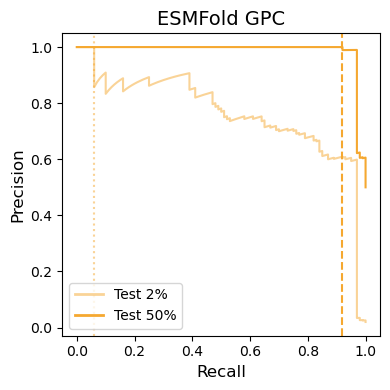


Combined Results
GPC Model,Test set,AUC,Accuracy,Average precision,Recall at 100% precision
AlphaFold3,Balanced (50%),0.99,0.79,0.993,0.77
AlphaFold3,Unbalanced (2%),0.983,0.626,0.894,0.27
AlphaFold2,Balanced (50%),0.98,0.86,0.986,0.78
AlphaFold2,Unbalanced (2%),0.963,0.74,0.866,0.46
ESMFold,Balanced (50%),0.981,0.88,0.988,0.92
ESMFold,Unbalanced (2%),0.975,0.787,0.767,0.06



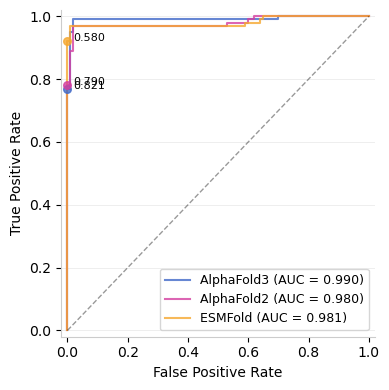

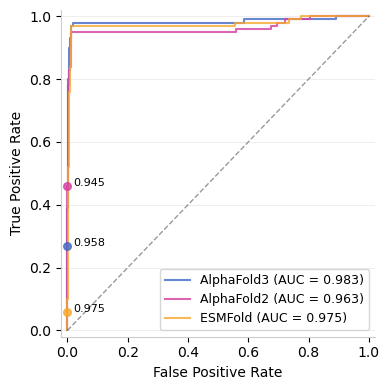


Running learning curves...

Learning curves for AlphaFold3...
  Test_50%: 200 total (AntiFam: 100, Swiss-Prot: 100)
  Test_2%: 4925 total (AntiFam: 100, Swiss-Prot: 4825)
   10% (~55: AntiFam: ~27, Swiss-Prot: ~27)
    [Test_50%] AUC                      : 0.970 ± 0.009
    [Test_50%] ACCURACY                 : 0.811 ± 0.049
    [Test_50%] AVERAGE_PRECISION        : 0.978 ± 0.007
    [Test_50%] RECALL_AT_100_PRECISION  : 0.714 ± 0.123
    [Test_2%] AUC                      : 0.972 ± 0.008
    [Test_2%] ACCURACY                 : 0.693 ± 0.084
    [Test_2%] AVERAGE_PRECISION        : 0.856 ± 0.025
    [Test_2%] RECALL_AT_100_PRECISION  : 0.316 ± 0.136
   25% (~138: AntiFam: ~69, Swiss-Prot: ~69)
    [Test_50%] AUC                      : 0.974 ± 0.015
    [Test_50%] ACCURACY                 : 0.801 ± 0.054
    [Test_50%] AVERAGE_PRECISION        : 0.981 ± 0.011
    [Test_50%] RECALL_AT_100_PRECISION  : 0.744 ± 0.045
    [Test_2%] AUC                      : 0.974 ± 0.009
    [Test_2%] AC

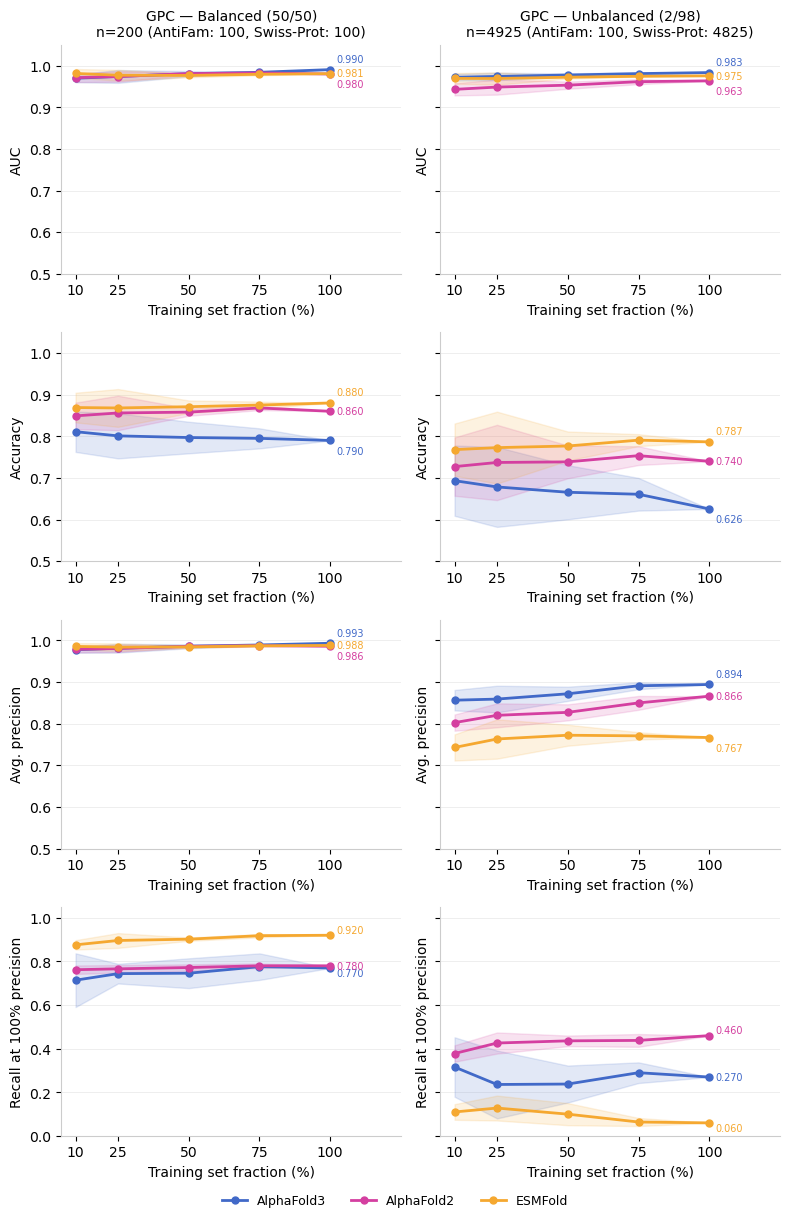


Plateau report (Test_2% — unbalanced)

  AUC
    AlphaFold3: plateaued
      Final:        0.983 ± 0.000
      Gain 75→100%: +0.003
      Gain 50→100%: +0.006
      All means:    [np.float64(0.972), np.float64(0.974), np.float64(0.977), np.float64(0.981), np.float64(0.983)]
    AlphaFold2: plateaued
      Final:        0.963 ± 0.000
      Gain 75→100%: +0.002
      Gain 50→100%: +0.010
      All means:    [np.float64(0.943), np.float64(0.948), np.float64(0.953), np.float64(0.961), np.float64(0.963)]
    ESMFold: plateaued
      Final:        0.975 ± 0.000
      Gain 75→100%: +0.001
      Gain 50→100%: +0.003
      All means:    [np.float64(0.969), np.float64(0.969), np.float64(0.972), np.float64(0.974), np.float64(0.975)]

  Accuracy
    AlphaFold3: degrading
      Final:        0.626 ± 0.000
      Gain 75→100%: -0.035
      Gain 50→100%: -0.040
      All means:    [np.float64(0.693), np.float64(0.678), np.float64(0.666), np.float64(0.661), np.float64(0.626)]
    AlphaFold2: plateaued

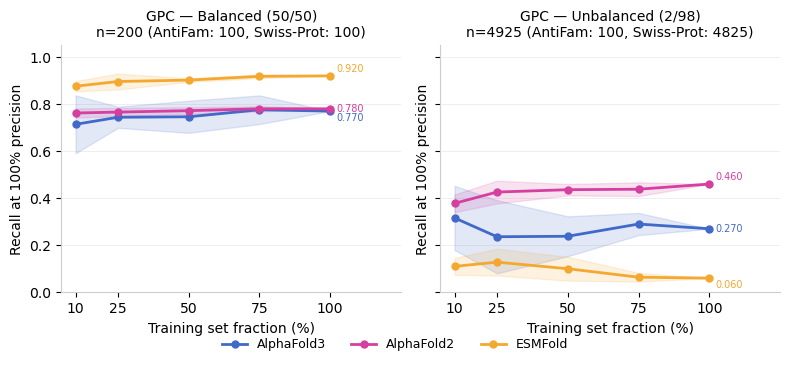


Building resampling draws...

Resampling pools: AF=1275, SP=4825
  Balanced draw:   100 AF + 100 SP
  Unbalanced draw: 20 AF + 980 SP (~2.0% prevalence)
  AlphaFold3: 100 draws built (balanced + unbalanced)
  AlphaFold2: 100 draws built (balanced + unbalanced)
  ESMFold: 100 draws built (balanced + unbalanced)

Running resampling evaluation...

Evaluating AlphaFold3...

  [balanced]
    auc                      : 0.986 [0.970-1.000]
    average_precision        : 0.990 [0.972-1.000]
    accuracy                 : 0.801 [0.752-0.848]
    recall_at_100_precision  : 0.803 [0.219-0.990]

  [unbalanced]
    auc                      : 0.987 [0.942-0.999]
    average_precision        : 0.881 [0.767-0.980]
    accuracy                 : 0.628 [0.597-0.654]
    recall_at_100_precision  : 0.472 [0.150-0.926]

Evaluating AlphaFold2...

  [balanced]
    auc                      : 0.981 [0.962-0.999]
    average_precision        : 0.987 [0.974-0.998]
    accuracy                 : 0.854 [0.815-0.8

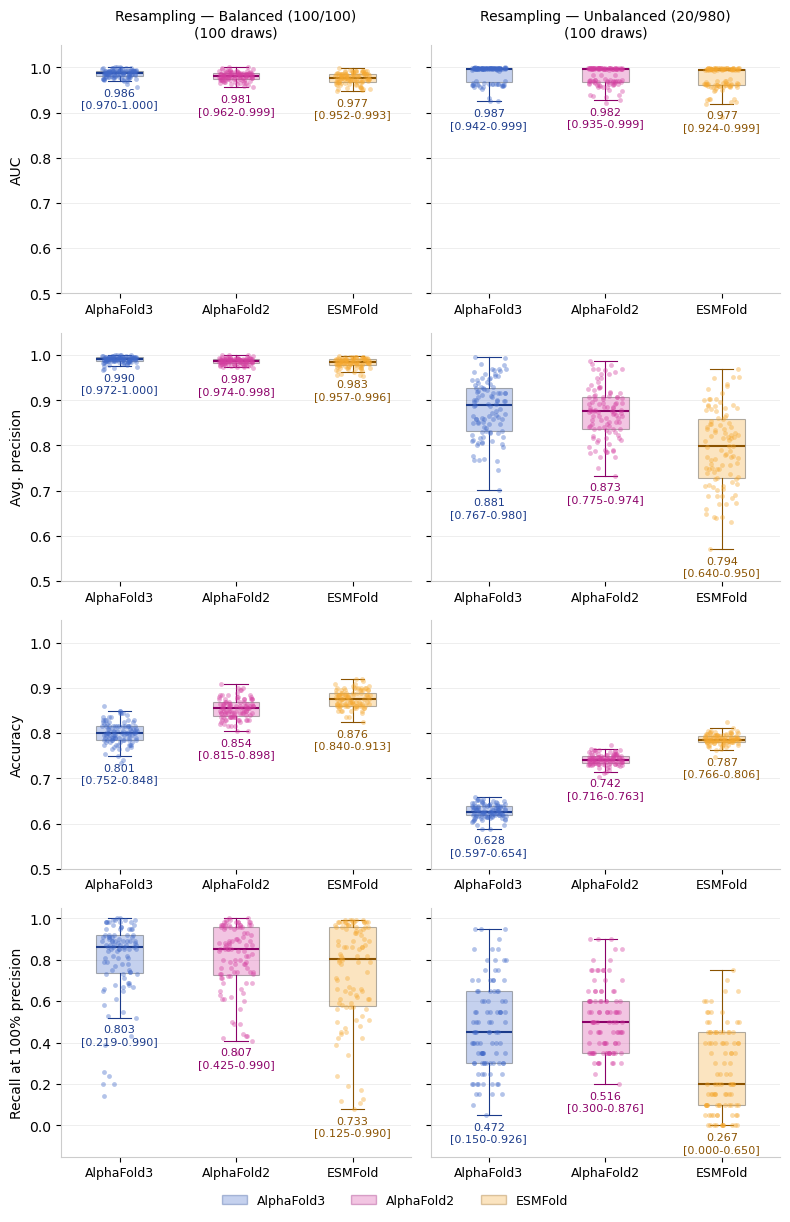

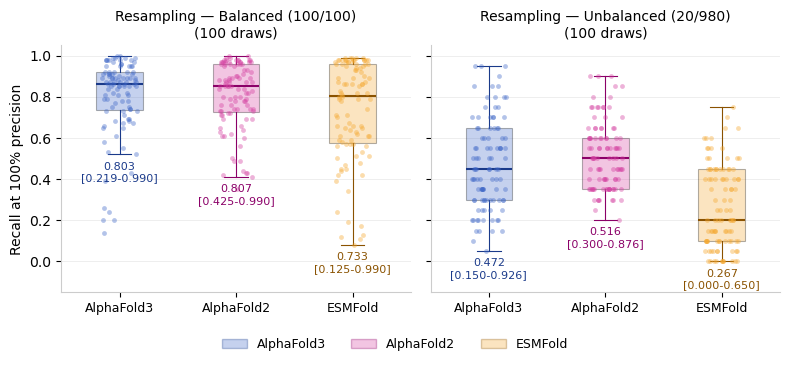

In [14]:
def run_model_pipeline(model, config):
    feature_cols = config["feats"]
    pos_label = config["pos_label"]
    print(f"\n{'=' * 60}\nRunning pipeline for: {model['name']}\n{'=' * 60}")

    cv = cross_validate_model(model["training"], config)
    print(f"  CV AUC:          {cv['cv_auc_mean']:.3f} ± {cv['cv_auc_std']:.3f}")
    print(f"  CV Recall@100P:  {cv['cv_recall_mean']:.3f} ± {cv['cv_recall_std']:.3f}")

    X_train = model["training"][feature_cols].values
    y_train = model["training"]["source"].values
    trained_model, scaler = train_gpc_model(X_train, y_train, config["random_state"])
    model["trained_model"] = trained_model
    model["scaler"] = scaler

    results, roc_curves, pr_curves = [], {}, {}
    for test_name, test_df in model["testing"].items():
        X_test = test_df[feature_cols].values
        y_test = test_df["source"].values
        y_binary = (y_test == pos_label).astype(int)
        y_proba = get_predictions(trained_model, scaler, X_test, pos_label)
        m = compute_metrics(y_binary, y_proba)

        opt_thresh, tpr_at_fpr0, _ = find_optimal_threshold_at_fpr_zero(
            m["fpr"], m["tpr"], m["roc_thresholds"]
        )
        recall_at_100, _ = find_recall_at_100_precision(m["precision"], m["recall"])

        roc_curves[test_name] = {
            "fpr": m["fpr"],
            "tpr": m["tpr"],
            "thresholds": m["roc_thresholds"],
            "auc": m["auc"],
        }
        pr_curves[test_name] = {
            "precision": m["precision"],
            "recall": m["recall"],
            "thresholds": m["pr_thresholds"],
            "average_precision": m["average_precision"],
        }
        results.append(
            {
                "test_set": test_name,
                "auc": m["auc"],
                "average_precision": m["average_precision"],
                "accuracy": m["accuracy"],
                "f1": m["f1"],
                "tpr_at_fpr_zero": tpr_at_fpr0,
                "optimal_threshold": opt_thresh,
                "recall_at_100_precision": recall_at_100,
                **{k: cv[k] for k in cv},
            }
        )

    results_df = pd.DataFrame(results)
    print("\nTest Set Results:")
    print(results_df.to_string(index=False))
    plot_precision_recall_curves(pr_curves, model["name"], model["color"])
    model["pr_curves"] = pr_curves

    return results_df, roc_curves


def run_all_models():
    all_roc_data, all_results = [], []

    for model_key, model in MODELS.items():
        results_df, roc_curves = run_model_pipeline(model, CONFIG)
        results_df["model"] = model["name"]
        all_results.append(results_df)
        all_roc_data.append(
            {
                "name": model["name"],
                "color": model["color"],
                "roc_curves": roc_curves,
            }
        )

    combined = pd.concat(all_results, ignore_index=True)

    print(f"\n{'=' * 60}\nCombined Results\n{'=' * 60}")
    summary_cols = [
        "model",
        "test_set",
        "auc",
        "accuracy",
        "average_precision",
        "recall_at_100_precision",
    ]

    table_df = combined[summary_cols].round(3).copy()
    table_df.columns = [
        "GPC Model",
        "Test set",
        "AUC",
        "Accuracy",
        "Average precision",
        "Recall at 100% precision",
    ]
    table_df["Test set"] = table_df["Test set"].map(
        {
            "Test_50%": "Balanced (50%)",
            "Test_2%": "Unbalanced (2%)",
        }
    )

    print(table_df.to_csv(index=False))

    plot_combined_roc_curves(all_roc_data, "Test_50%")
    plot_combined_roc_curves(all_roc_data, "Test_2%")
    # plot_all_pr_curves(
    #     [(m["name"], m["color"], m["pr_curves"]) for m in MODELS.values()]
    # )
    return combined, all_roc_data


# %%
def prepare_all_models():
    rs = CONFIG["random_state"]
    cols = ["id"] + CONFIG["feats"] + ["source"]

    for model_info in MODELS.values():
        model_info["data"] = {
            split: load_csv(
                f"{src['dir']}/{src['prefix']}{model_info['file']}",
                src["source"],
                src.get("af_source"),
            )
            for split, src in DATA_SOURCES.items()
        }

    for model_info in MODELS.values():
        data = model_info["data"]
        model_info["training"] = pd.concat([data["af_train"], data["sp_train"]])[cols]

        model_info["population"] = {
            "af": data["af_test"][cols].reset_index(drop=True),
            "sp": data["sp_test2"][cols],
        }

        print(
            f"  {model_info['name']} — "
            f"train: {len(model_info['training'])}, "
            f"AF pool: {len(model_info['population']['af'])}, "
            f"SP pool: {len(model_info['population']['sp'])}"
        )


def build_test_sets(n_draws=100, n_per_class=100, seed_start=0):
    """
    build 100 test sets of 100 per class for resampling analysis
    then re-run to build one test of 300 per class
    Randomly draw n_per_class AF + n_per_class SP from the pooled
    test sequences, n_draws times.
    """
    cols = ["id"] + CONFIG["feats"] + ["source"]
    test_set_collection = {}

    for model_key, model in MODELS.items():
        af_pool = model["population"]["af"].sort_values("id").reset_index(drop=True)
        sp_pool = model["population"]["sp"].sort_values("id").reset_index(drop=True)

        model["population"]["af"] = af_pool
        model["population"]["sp"] = sp_pool

        print(f"\n{model['name']} pool: AF={len(af_pool)}, SP={len(sp_pool)}")

        draws = []
        for i in range(n_draws):
            af_s = af_pool.sample(
                n=min(n_per_class, len(af_pool)),
                random_state=seed_start + i,
                replace=len(af_pool) < n_per_class,
            )
            sp_s = sp_pool.sample(
                n=min(n_per_class, len(sp_pool)),
                random_state=seed_start + i,
                replace=len(sp_pool) < n_per_class,
            )
            draws.append(pd.concat([af_s, sp_s]).reset_index(drop=True))

        test_set_collection[model_key] = {"draws": draws}

        model["testing"] = {
            "Test_50%": draws[0],
            "Test_2%": pd.concat(
                [
                    model["data"]["af_test"][cols].sample(
                        n=min(100, len(model["data"]["af_test"])),
                        random_state=CONFIG["random_state"],
                    ),
                    model["data"]["sp_test2"][cols],
                ]
            ).reset_index(drop=True),
        }

        print(f"\n{model['name']} final sets:")

        # Training set
        train_af = model["training"][model["training"]["source"] == "AntiFam"]
        train_sp = model["training"][model["training"]["source"] == "Swiss-Prot"]
        train_af_len = train_af["length"]
        train_sp_len = train_sp["length"]
        print(
            f"  Training: AF={train_af_len.min()}-{train_af_len.max()} "
            f"(avg: {train_af_len.mean():.2f}), "
            f"SP={train_sp_len.min()}-{train_sp_len.max()} "
            f"(avg: {train_sp_len.mean():.2f})"
        )

        # Test_50% set
        test50_af = model["testing"]["Test_50%"][
            model["testing"]["Test_50%"]["source"] == "AntiFam"
        ]
        test50_sp = model["testing"]["Test_50%"][
            model["testing"]["Test_50%"]["source"] == "Swiss-Prot"
        ]
        test50_af_len = test50_af["length"]
        test50_sp_len = test50_sp["length"]
        print(
            f"  Test_50%: AF={test50_af_len.min()}-{test50_af_len.max()} "
            f"(avg: {test50_af_len.mean():.2f}), "
            f"SP={test50_sp_len.min()}-{test50_sp_len.max()} "
            f"(avg: {test50_sp_len.mean():.2f})"
        )

        # Test_2% set
        test2_af = model["testing"]["Test_2%"][
            model["testing"]["Test_2%"]["source"] == "AntiFam"
        ]
        test2_sp = model["testing"]["Test_2%"][
            model["testing"]["Test_2%"]["source"] == "Swiss-Prot"
        ]
        test2_af_len = test2_af["length"]
        test2_sp_len = test2_sp["length"]
        print(
            f"  Test_2%:  AF={test2_af_len.min()}-{test2_af_len.max()} "
            f"(avg: {test2_af_len.mean():.2f}), "
            f"SP={test2_sp_len.min()}-{test2_sp_len.max()} "
            f"(avg: {test2_sp_len.mean():.2f})"
        )

        print(f"  {n_draws} draws of {n_per_class} AF + {n_per_class} SP")
        print(
            f"  Test_2%: AF={min(100, len(model['data']['af_test']))}, "
            f"SP={len(model['data']['sp_test2'])}"
        )

    return test_set_collection


def build_resampling_draws(n_draws=100, seed_start=0):
    """
    Build n_draws resampling test sets in two compositions:
      balanced:   100 AF + 100 SP  (~50% prevalence)
      unbalanced:  20 AF + 980 SP  (~2% prevalence)

    SP drawn from full test2 SP pool.
    AF drawn from full synthetic AF pool.
    The same draw id sets are used across all models.
    """
    ref_model = next(iter(MODELS.values()))
    af_pool_ref = ref_model["population"]["af"]
    sp_pool_ref = ref_model["population"]["sp"]

    balanced_cfg = CONFIG["resample_balanced"]
    unbalanced_cfg = CONFIG["resample_unbalanced"]

    print(f"\nResampling pools: AF={len(af_pool_ref)}, SP={len(sp_pool_ref)}")
    print(f"  Balanced draw:   {balanced_cfg['n_af']} AF + {balanced_cfg['n_sp']} SP")
    print(
        f"  Unbalanced draw: {unbalanced_cfg['n_af']} AF + {unbalanced_cfg['n_sp']} SP "
        f"(~{100 * unbalanced_cfg['n_af'] / (unbalanced_cfg['n_af'] + unbalanced_cfg['n_sp']):.1f}% prevalence)"
    )

    # determine draw id sets once from reference pools
    draw_id_sets = {"balanced": [], "unbalanced": []}
    for i in range(n_draws):
        for label, cfg in [("balanced", balanced_cfg), ("unbalanced", unbalanced_cfg)]:
            af_ids = set(
                af_pool_ref.sample(
                    n=min(cfg["n_af"], len(af_pool_ref)),
                    random_state=seed_start + i,
                    replace=len(af_pool_ref) < cfg["n_af"],
                )["id"]
            )
            sp_ids = set(
                sp_pool_ref.sample(
                    n=min(cfg["n_sp"], len(sp_pool_ref)),
                    random_state=seed_start + i,
                    replace=len(sp_pool_ref) < cfg["n_sp"],
                )["id"]
            )
            draw_id_sets[label].append({"af": af_ids, "sp": sp_ids})

    # slice each model to the shared draw id sets
    test_set_collection = {}
    for model_key, model in MODELS.items():
        af_pool = model["population"]["af"]
        sp_pool = model["population"]["sp"]

        draws = {"balanced": [], "unbalanced": []}
        for label in ["balanced", "unbalanced"]:
            for id_set in draw_id_sets[label]:
                af_draw = af_pool[af_pool["id"].isin(id_set["af"])].reset_index(
                    drop=True
                )
                sp_draw = sp_pool[sp_pool["id"].isin(id_set["sp"])].reset_index(
                    drop=True
                )
                draws[label].append(
                    pd.concat([af_draw, sp_draw]).reset_index(drop=True)
                )

        test_set_collection[model_key] = {"draws": draws}
        print(f"  {model['name']}: {n_draws} draws built (balanced + unbalanced)")

    return test_set_collection


def run_resampling_evaluation(test_set_collection):
    feature_cols = CONFIG["feats"]
    pos_label = CONFIG["pos_label"]
    all_results = {}

    for model_key, model in MODELS.items():
        print(f"\nEvaluating {model['name']}...")
        model_fit = model["trained_model"]
        scaler = model["scaler"]

        all_results[model_key] = {}

        for label in ["balanced", "unbalanced"]:
            draws = test_set_collection[model_key]["draws"][label]
            records = []
            for i, draw_df in enumerate(draws):
                y_binary = (draw_df["source"].values == pos_label).astype(int)
                y_proba = get_predictions(
                    model_fit, scaler, draw_df[feature_cols].values, pos_label
                )
                m = compute_metrics(y_binary, y_proba)
                recall_100, _ = find_recall_at_100_precision(
                    m["precision"], m["recall"]
                )
                records.append(
                    {
                        "draw_id": i,
                        **{k: m[k] for k in ["auc", "average_precision", "accuracy"]},
                        "recall_at_100_precision": recall_100,
                    }
                )

            draws_df = pd.DataFrame(records)
            summary = {}
            metrics = [
                "auc",
                "average_precision",
                "accuracy",
                "recall_at_100_precision",
            ]

            print(f"\n  [{label}]")
            for metric in metrics:
                vals = draws_df[metric].values
                summary[metric] = {
                    "mean": vals.mean(),
                    "ci_low": np.percentile(vals, 2.5),
                    "ci_high": np.percentile(vals, 97.5),
                    "std": vals.std(),
                    "values": vals,
                }
                print(
                    f"    {metric:25s}: {summary[metric]['mean']:.3f} "
                    f"[{summary[metric]['ci_low']:.3f}-{summary[metric]['ci_high']:.3f}]"
                )

            all_results[model_key][label] = {"draws_df": draws_df, "summary": summary}

    # Spearman correlations across models (per composition)
    model_keys = list(MODELS.keys())
    metrics = ["auc", "average_precision", "accuracy", "recall_at_100_precision"]
    for label in ["balanced", "unbalanced"]:
        print(f"\n--- Spearman correlations ({label}) ---")
        for metric in metrics:
            print(f"\n  {metric}")
            for i, mk1 in enumerate(model_keys):
                for mk2 in model_keys[i + 1 :]:
                    v1 = all_results[mk1][label]["draws_df"][metric].values
                    v2 = all_results[mk2][label]["draws_df"][metric].values
                    r, p = spearmanr(v1, v2)
                    print(f"    {mk1} vs {mk2}: r={r:.3f}, p={p:.4f}")

    return all_results


def plot_resampling_results(all_results, metrics=None):
    if metrics is None:
        metrics = ["auc", "average_precision", "accuracy", "recall_at_100_precision"]
    metric_labels = {
        "auc": "AUC",
        "average_precision": "Avg. precision",
        "accuracy": "Accuracy",
        "recall_at_100_precision": "Recall at 100% precision",
    }
    y_floors = {
        "auc": 0.5,
        "average_precision": 0.5,
        "accuracy": 0.5,
        "recall_at_100_precision": -0.15,
    }
    compositions = {
        "balanced": "Balanced (100/100)",
        "unbalanced": "Unbalanced (20/980)",
    }
    fig, axes = plt.subplots(
        len(metrics),
        len(compositions),
        figsize=(8, 3 * len(metrics)),
        sharey="row",
    )
    for row, metric in enumerate(metrics):
        for col, (label, comp_title) in enumerate(compositions.items()):
            ax = axes[row][col]
            for i, (model_key, model) in enumerate(MODELS.items()):
                color = model["color"]
                dark = DARK_COLORS[model_key]
                vals = all_results[model_key][label]["draws_df"][metric].values
                s = all_results[model_key][label]["summary"][metric]
                ax.boxplot(
                    [vals],
                    positions=[i],
                    widths=0.4,
                    patch_artist=True,
                    showfliers=False,
                    medianprops={"color": dark, "linewidth": 1.5},
                    boxprops={"facecolor": color, "alpha": 0.3, "linewidth": 0.8},
                    whiskerprops={"linewidth": 0.8, "color": dark},
                    capprops={"linewidth": 0.8, "color": dark},
                )
                rng = np.random.RandomState(42)
                jitter = rng.uniform(-0.15, 0.15, size=len(vals))
                ax.scatter(
                    np.full(len(vals), i) + jitter,
                    vals,
                    color=color,
                    alpha=0.4,
                    s=12,
                    linewidths=0,
                    zorder=3,
                )
                q1, q3 = np.percentile(vals, [25, 75])
                iqr = q3 - q1
                whisker_bottom = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())

                ax.annotate(
                    f"{s['mean']:.3f}\n[{s['ci_low']:.3f}-{s['ci_high']:.3f}]",
                    xy=(i, whisker_bottom),
                    xytext=(0, -5),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=8,
                    color=dark,
                )
            if row == 0:
                ax.set_title(f"Resampling — {comp_title}\n(100 draws)", fontsize=10)
            ax.set_ylabel(metric_labels[metric] if col == 0 else "", fontsize=10)
            ax.set_ylim(y_floors[metric], 1.05)
            ax.set_xticks(range(len(MODELS)))
            ax.set_xticklabels([m["name"] for m in MODELS.values()], fontsize=9)
            _style_ax(ax)

    handles = [
        mpatches.Patch(
            facecolor=model["color"],
            alpha=0.3,
            edgecolor=DARK_COLORS[model_key],
            label=model["name"],
        )
        for model_key, model in MODELS.items()
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(MODELS),
        fontsize=9,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.6)  # make room for the legend
    plt.tight_layout()
    fig.savefig("resampling_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_recall_resampling(all_results):
    metric = "recall_at_100_precision"
    compositions = {
        "balanced": "Balanced (100/100)",
        "unbalanced": "Unbalanced (20/980)",
    }

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

    for col, (label, comp_title) in enumerate(compositions.items()):
        ax = axes[col]

        for i, (model_key, model) in enumerate(MODELS.items()):
            color = model["color"]
            dark = DARK_COLORS[model_key]
            vals = all_results[model_key][label]["draws_df"][metric].values
            s = all_results[model_key][label]["summary"][metric]

            ax.boxplot(
                [vals],
                positions=[i],
                widths=0.4,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": dark, "linewidth": 1.5},
                boxprops={"facecolor": color, "alpha": 0.3, "linewidth": 0.8},
                whiskerprops={"linewidth": 0.8, "color": dark},
                capprops={"linewidth": 0.8, "color": dark},
            )

            rng = np.random.RandomState(42)
            jitter = rng.uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(
                np.full(len(vals), i) + jitter,
                vals,
                color=color,
                alpha=0.4,
                s=12,
                linewidths=0,
                zorder=3,
            )

            q1, q3 = np.percentile(vals, [25, 75])
            iqr = q3 - q1
            whisker_bottom = max(vals[vals >= q1 - 1.5 * iqr].min(), vals.min())

            ax.annotate(
                f"{s['mean']:.3f}\n[{s['ci_low']:.3f}-{s['ci_high']:.3f}]",
                xy=(i, whisker_bottom),
                xytext=(0, -5),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=8,
                color=dark,
            )

        ax.set_title(f"Resampling — {comp_title}\n(100 draws)", fontsize=10)
        ax.set_ylabel("Recall at 100% precision" if col == 0 else "", fontsize=10)
        ax.set_ylim(-0.15, 1.05)
        ax.set_xticks(range(len(MODELS)))
        ax.set_xticklabels([m["name"] for m in MODELS.values()], fontsize=9)
        _style_ax(ax)

    handles = [
        mpatches.Patch(
            facecolor=model["color"],
            alpha=0.3,
            edgecolor=DARK_COLORS[model_key],
            label=model["name"],
        )
        for model_key, model in MODELS.items()
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(MODELS),
        fontsize=9,
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
    )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    fig.savefig("recall_resampling.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────

prepare_all_models()

print("\nBuilding test sets...")
test_set_collection = build_test_sets(n_draws=100, n_per_class=100, seed_start=0)

results_df, roc_data = run_all_models()

print("\nRunning learning curves...")
lc_results = run_learning_curves(fractions=[0.10, 0.25, 0.50, 0.75, 1.00], n_seeds=5)
plateau_report = plot_learning_curves(lc_results)
plot_recall_learning_curves(lc_results)

print("\nBuilding resampling draws...")
resample_draws = build_resampling_draws(n_draws=100, seed_start=0)

print("\nRunning resampling evaluation...")
resample_results = run_resampling_evaluation(resample_draws)
plot_resampling_results(resample_results)
plot_recall_resampling(resample_results)
# %%
